# Taller: Regresión Logística con `scikit-learn`

Este notebook muestra una versión del taller usando **regresión logística con `scikit-learn`**.

Se trabaja paso a paso con:
- carga de datos,
- preparación del conjunto,
- entrenamiento del modelo,
- matriz de confusión,
- métricas de clasificación,
- curva ROC y AUC.

El ejemplo usa el conjunto de datos de diabetes disponible en `OpenML`.


In [ ]:
# Ejecutar solo si hace falta en Google Colab
# !pip install pandas numpy matplotlib seaborn scikit-learn openml


## Importación de librerías y carga de datos

1.   Elemento de lista
2.   Elemento de lista



En esta sección:
- importamos las librerías necesarias,
- descargamos el conjunto de datos,
- y revisamos sus primeras filas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

# Configuración visual básica para gráficos
plt.rcParams["figure.figsize"] = (7, 5)
sns.set_theme(style="whitegrid")

# Cargar dataset desde OpenML
data = fetch_openml(name="diabetes", version=1, as_frame=True)
df = data.frame.copy()

# Mostrar tamaño y primeras filas
print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (768, 9)


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


## Preparación de los datos

La variable objetivo es `class`, que contiene dos categorías:
- `tested_negative`
- `tested_positive`

La convertiremos a valores numéricos:
- 0 = negativo
- 1 = positivo


In [2]:
# Convertir la variable objetivo a formato categórico
df["class"] = df["class"].astype("category")

# Separar variables predictoras (X) y variable objetivo (y)
X = df.drop(columns="class")
y = df["class"].cat.codes   # 0 = tested_negative, 1 = tested_positive

# Verificar distribución de clases
print("Conteo por clase:")
print(df["class"].value_counts())
print("\nPrimeras filas de X:")
display(X.head())
print("\nPrimeros valores de y:")
print(y[:10].tolist())


Conteo por clase:
class
tested_negative    500
tested_positive    268
Name: count, dtype: int64

Primeras filas de X:


,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33



Primeros valores de y:
[1, 0, 1, 0, 1, 0, 1, 0, 1, 1]


## División en entrenamiento y prueba

Separamos los datos en:
- **80% para entrenamiento**
- **20% para prueba**

Además, usamos `stratify=y` para mantener una proporción similar de clases en ambos conjuntos.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=58,
    stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test :", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test :", y_test.shape)


Tamaño de X_train: (614, 8)
Tamaño de X_test : (154, 8)
Tamaño de y_train: (614,)
Tamaño de y_test : (154,)


## Creación y entrenamiento del modelo

Aquí usamos:

1. `StandardScaler()`: estandariza las variables numéricas.
2. `LogisticRegression()`: entrena el modelo de clasificación.

Esto es una práctica recomendable porque la regresión logística suele funcionar mejor cuando las variables están en una escala comparable.


In [17]:
# ============================================================
# 3. Mostrar datos antes del escalado
# ============================================================
print("Datos originales de entrenamiento:")
display(X_train.head())

print("Datos originales de prueba:")
display(X_test.head())

Datos originales de entrenamiento:


,preg,plas,pres,skin,insu,mass,pedi,age
350,4,92,80,0,0,42.2,0.237,29
381,0,105,68,22,0,20.0,0.236,22
461,1,71,62,0,0,21.8,0.416,26
71,5,139,64,35,140,28.6,0.411,26
672,10,68,106,23,49,35.5,0.285,47


Datos originales de prueba:


,preg,plas,pres,skin,insu,mass,pedi,age
186,8,181,68,36,495,30.1,0.615,60
530,2,122,60,18,106,29.8,0.717,22
757,0,123,72,0,0,36.3,0.258,52
421,2,94,68,18,76,26.0,0.561,21
716,3,173,78,39,185,33.8,0.970,31


In [18]:
# ============================================================
# 4. Escalar datos
# ============================================================
# El escalador se ajusta SOLO con entrenamiento
# Luego transforma entrenamiento y prueba
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame solo para visualizar mejor
X_train_scaled_df = pd.DataFrame(
    X_train_scaled, columns=X_train.columns, index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled, columns=X_test.columns, index=X_test.index
)


In [19]:
# ============================================================
# 5. Mostrar datos después del escalado
# ============================================================
print("Datos escalados de entrenamiento:")
display(X_train_scaled_df.head())

print("Datos escalados de prueba:")
display(X_test_scaled_df.head())

Datos escalados de entrenamiento:


,preg,plas,pres,skin,insu,mass,pedi,age
350,0.041904,-0.951428,0.552800,-1.261723,-0.686799,1.273343,-0.705005,-0.354454
381,-1.154791,-0.525404,-0.071515,0.090495,-0.686799,-1.510541,-0.708068,-0.944478
461,-0.855618,-1.639620,-0.383672,-1.261723,-0.686799,-1.284821,-0.156774,-0.607321
71,0.341078,0.588812,-0.279620,0.889533,0.531041,-0.432100,-0.172087,-0.607321
672,1.836947,-1.737934,1.905483,0.151959,-0.260555,0.433162,-0.557994,1.162751


Datos escalados de prueba:


,preg,plas,pres,skin,insu,mass,pedi,age
186,1.238599,1.965196,-0.071515,0.950997,3.619134,-0.243999,0.452713,2.258510
530,-0.556444,0.031704,-0.487725,-0.155363,0.235280,-0.281619,0.765113,-0.944478
757,-1.154791,0.064475,0.136590,-1.261723,-0.686799,0.533482,-0.640688,1.584197
421,-0.556444,-0.885886,-0.071515,-0.155363,-0.025686,-0.758140,0.287325,-1.028767
716,-0.257270,1.703028,0.448748,1.135391,0.922489,0.219981,1.539988,-0.185875


In [20]:
# ============================================================
# 6. Entrenar modelo de regresión logística
# ============================================================
# Se recomienda liblinear para problemas binarios pequeños/medianos
modelo = LogisticRegression(
    max_iter=1000,
    random_state=58,
    solver="liblinear"
)

modelo.fit(X_train_scaled, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## Predicciones del modelo

Generaremos dos tipos de salida:

- `y_pred`: clase predicha (0 o 1)
- `y_prob`: probabilidad estimada de pertenecer a la clase positiva


In [21]:
# ============================================================
# 7. Realizar predicciones
# ============================================================
# IMPORTANTE:
# Las predicciones deben hacerse con los datos escalados,
# no con X_test original.
y_pred = modelo.predict(X_test_scaled)

# Probabilidad de pertenecer a la clase positiva
y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

print("Primeras 10 predicciones:")
print(y_pred[:10])

print("\nPrimeras 10 probabilidades:")
print(np.round(y_prob[:10], 4))


Primeras 10 predicciones:
[1 0 0 0 1 0 0 1 1 0]

Primeras 10 probabilidades:
[0.8537 0.2347 0.3097 0.0603 0.7661 0.2857 0.4868 0.6958 0.7902 0.102 ]


## Matriz de confusión

La matriz de confusión permite comparar:
- lo que **realmente ocurrió**,
- versus lo que **el modelo predijo**.


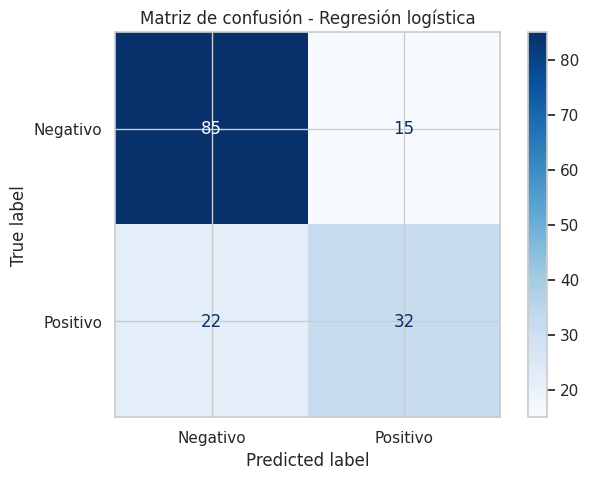

Matriz de confusión:
[[85 15]
 [22 32]]


In [23]:
# ============================================================
# 9. Matriz de confusión
# ============================================================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativo", "Positivo"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Regresión logística")
plt.show()

print("Matriz de confusión:")
print(cm)

### Interpretación de la matriz de confusión

La matriz de confusión permite evaluar el desempeño del modelo comparando las predicciones con los valores reales.

- **Verdaderos negativos (TN):** casos negativos correctamente clasificados.
- **Falsos positivos (FP):** casos negativos clasificados como positivos.
- **Falsos negativos (FN):** casos positivos clasificados como negativos.
- **Verdaderos positivos (TP):** casos positivos correctamente clasificados.

Un buen modelo concentra la mayor cantidad de observaciones en la **diagonal principal**.

## Métricas de clasificación

Ahora calcularemos las métricas más comunes para evaluar un modelo de clasificación:

- **Accuracy**
- **Precision**
- **Recall**
- **Sensibilidad**
- **F1-score**
- **AUC**


In [25]:
# ============================================================
# 11. Métricas de clasificación
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
sensibilidad = recall   # En clasificación binaria, es equivalente
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Métricas del modelo:")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Sensibilidad : {sensibilidad:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"AUC          : {auc:.4f}")


Métricas del modelo:
Accuracy     : 0.7597
Precision    : 0.6809
Recall       : 0.5926
Sensibilidad : 0.5926
F1-score     : 0.6337
AUC          : 0.8231


### Nota: explicación simple de las métricas

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** de todos los casos que el modelo marcó como positivos, cuántos realmente eran positivos.
- **Recall:** de todos los casos positivos reales, cuántos logró detectar el modelo.
- **Sensibilidad:** es otro nombre para el **recall** en clasificación binaria.
- **F1-score:** combina precision y recall en una sola medida.
- **AUC:** resume qué tan bien el modelo separa la clase negativa de la positiva.

Interpretación general:
- si **accuracy** es alta, el modelo acierta con frecuencia;
- si **recall/sensibilidad** es alta, detecta bien los positivos;
- si **precision** es alta, se equivoca menos al anunciar positivos;
- si **F1** es alta, existe buen equilibrio entre precision y recall;
- si **AUC** se acerca a 1, el modelo discrimina muy bien entre ambas clases.


In [26]:
# ============================================================
# 13. Reporte de clasificación
# ============================================================
print(classification_report(y_test, y_pred, target_names=["Negativo", "Positivo"]))

              precision    recall  f1-score   support

    Negativo       0.79      0.85      0.82       100
    Positivo       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



## 8. Curva ROC

La curva ROC muestra cómo cambia el desempeño del modelo para distintos umbrales de decisión.

El valor **AUC** resume esa curva:
- cerca de **0.5**: desempeño débil,
- cerca de **1.0**: muy buena separación entre clases.


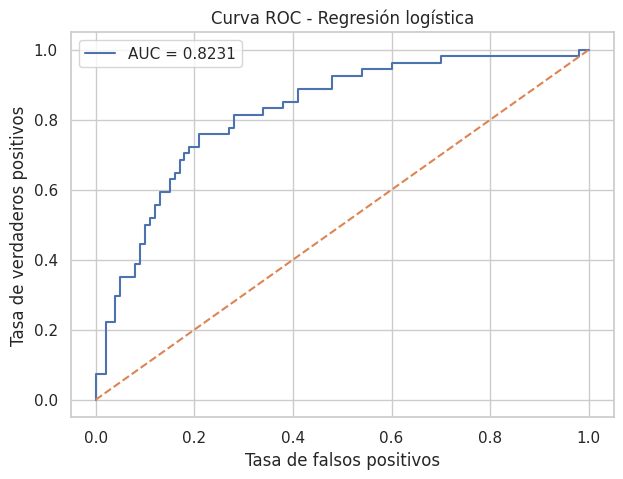

In [27]:
# ============================================================
# 14. Curva ROC
# ============================================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Regresión logística")
plt.legend()
plt.grid(True)
plt.show()
